 Sử dụng thư viện sklearn huấn luyện mô hình Gaussian Mixture thực hiện tác vụ xóa nền của tấm ảnh.

## 1. Import Libraries & Loading Image

In [1]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\MaiVu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Import libraries
from matplotlib import pyplot as plt
import cv2 as cv
import numpy as np

# Load the image
image = cv.imread("images/zebra.jpg") 

# Get image dimensions
img_h, img_w, img_c = image.shape

# Check shape
image.shape

(391, 586, 3)

## 2. Preprocessing

In [3]:
# Reshape image data for the model
# Chuyển đổi từ mảng 3D (h, w, c) sang mảng 2D (pixel, c)
image_data = image.reshape((-1, 3))

# Check data shape
image_data.shape

(229126, 3)

## 3. Gaussian Mixture Model

Mục đích: Khởi tạo và huấn luyện mô hình để phân cụm các pixel (Foreground và Background).

In [4]:
from sklearn.mixture import GaussianMixture

# Initialize GMM
# n_components=2: Chia ảnh thành 2 phần (nền và đối tượng)
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)

# Fit the model
gmm.fit(image_data)

,n_components,2
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,0


## 4. Prediction & Reshaping

Mục đích: Gán nhãn cho từng pixel và đưa mảng nhãn về kích thước ảnh ban đầu.

In [5]:
# Predict labels for each pixel
labels = gmm.predict(image_data)

# Check labels shape
# Output trong hình: (58800,) tương ứng với 196*300
print(labels.shape) 

# Reshape labels back to original image dimensions
labels = labels.reshape((img_h, img_w, 1))

(229126,)


## 5. Visualize Labels

Mục đích: Xem kết quả phân cụm dưới dạng mặt nạ (mask).

tối-0, sáng-1

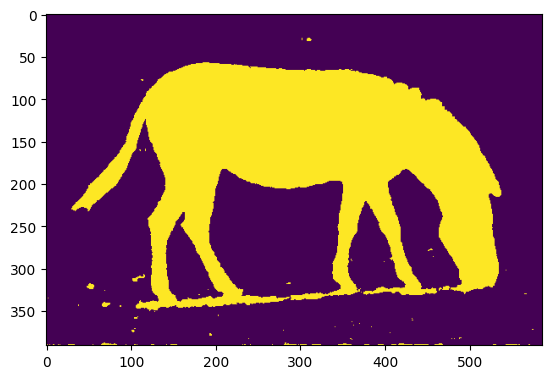

In [6]:
plt.imshow(labels)

## 6. Background removing

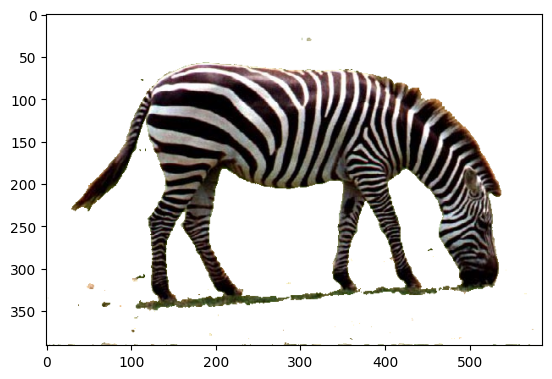

In [7]:
# Create an empty array for the segmented image
segmented_image = np.zeros_like(image)

# Apply the mask
# Logic: Nếu nhãn là 0 (background) thì gán giá trị 255 (màu trắng).
# Ngược lại (foreground) thì giữ nguyên pixel của ảnh gốc.
segmented_image = np.where(labels == 0, 255, image).astype(np.uint8)

# Show the final result
plt.imshow(cv.cvtColor(segmented_image, cv.COLOR_BGR2RGB))